In [7]:
import os
import kagglehub
import shutil
import pandas as pd


path = kagglehub.dataset_download("crawford/80-cereals")
print("Fichiers téléchargés dans :", path)
# Dossier de destination
dest = "data"
os.makedirs(dest, exist_ok=True)

# Copier tous les fichiers du dossier téléchargé vers /data
for fichier in os.listdir(path):
    src_file = os.path.join(path, fichier)
    dst_file = os.path.join(dest, fichier)
    shutil.copy2(src_file, dst_file)

print("Fichiers copiés dans :", dest)

Fichiers téléchargés dans : /home/onyxia/.cache/kagglehub/datasets/crawford/80-cereals/versions/2
Fichiers copiés dans : data


In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [26]:
df=pd.read_csv('data/cereal.csv')

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model=keras.Sequential([
    layers.Dense(units=1,input_shape=[3])
])
#units define how many outputs we want : for example, we just want to predict calories, so we want units=1
#input_shape tells keras the dimmensions of the inputs : for example here we want inputs to be such as ('sugars', 'fiber', and 'protein')
#so input_shape[3]

/opt/python/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
X=df[['sugars', 'fiber', 'protein']]
y=df[['calories']]

In [60]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [68]:
model.compile(
    optimizer='adam',
    loss='mae' #erreur absolue moyenne, adaptée à la régression
)
#avant de chercher à fit, il faut dire au modèle quel fonction de perte il utilise (ici MAE), et quel optimizer (Adaptive Moment Estimation)

history=model.fit(X_train_scaled,y_train_scaled, validation_data=(X_test_scaled, y_test_scaled),
epochs=100,
batch_size=30,
verbose=-1
)
#Une epoch, c'est un passage complet sur l'ensemble des données

Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78

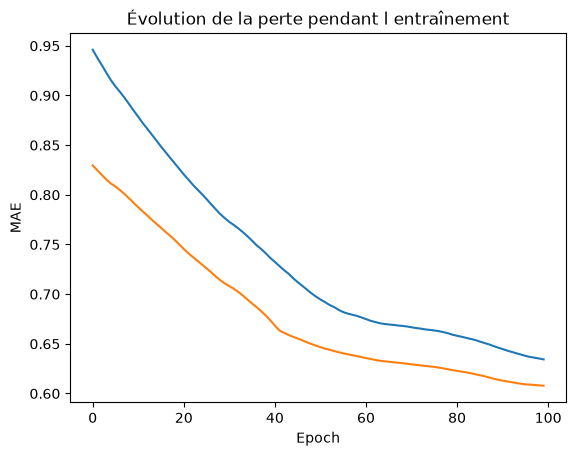

In [69]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Évolution de la perte pendant l entraînement')
plt.show()

In [64]:
loss=model.evaluate(X_test,y_test)
print('MAE sur le test ',loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 59.9434
MAE sur le test  59.94341278076172


In [71]:
model=keras.Sequential([
    layers.Dense(units=4,activation='relu',input_shape=[3]),
    layers.Dense(units=3,activation='relu'),
    layers.Dense(units=1)
])
#units define how many outputs we want : for example, we just want to predict calories, so we want units=1
#input_shape tells keras the dimmensions of the inputs : for example here we want inputs to be such as ('sugars', 'fiber', and 'protein')
#so input_shape[3]

In [75]:
model.compile(optimizer='adam',loss='mae')

history=model.fit(X_train_scaled,y_train_scaled,validation_data=(X_test_scaled,y_test_scaled),
epochs=300,
batch_size=30,
verbose=-1
)

Epoch 1/300
Epoch 2/300
Epoch 3/300
Epoch 4/300
Epoch 5/300
Epoch 6/300
Epoch 7/300
Epoch 8/300
Epoch 9/300
Epoch 10/300
Epoch 11/300
Epoch 12/300
Epoch 13/300
Epoch 14/300
Epoch 15/300
Epoch 16/300
Epoch 17/300
Epoch 18/300
Epoch 19/300
Epoch 20/300
Epoch 21/300
Epoch 22/300
Epoch 23/300
Epoch 24/300
Epoch 25/300
Epoch 26/300
Epoch 27/300
Epoch 28/300
Epoch 29/300
Epoch 30/300
Epoch 31/300
Epoch 32/300
Epoch 33/300
Epoch 34/300
Epoch 35/300
Epoch 36/300
Epoch 37/300
Epoch 38/300
Epoch 39/300
Epoch 40/300
Epoch 41/300
Epoch 42/300
Epoch 43/300
Epoch 44/300
Epoch 45/300
Epoch 46/300
Epoch 47/300
Epoch 48/300
Epoch 49/300
Epoch 50/300
Epoch 51/300
Epoch 52/300
Epoch 53/300
Epoch 54/300
Epoch 55/300
Epoch 56/300
Epoch 57/300
Epoch 58/300
Epoch 59/300
Epoch 60/300
Epoch 61/300
Epoch 62/300
Epoch 63/300
Epoch 64/300
Epoch 65/300
Epoch 66/300
Epoch 67/300
Epoch 68/300
Epoch 69/300
Epoch 70/300
Epoch 71/300
Epoch 72/300
Epoch 73/300
Epoch 74/300
Epoch 75/300
Epoch 76/300
Epoch 77/300
Epoch 78

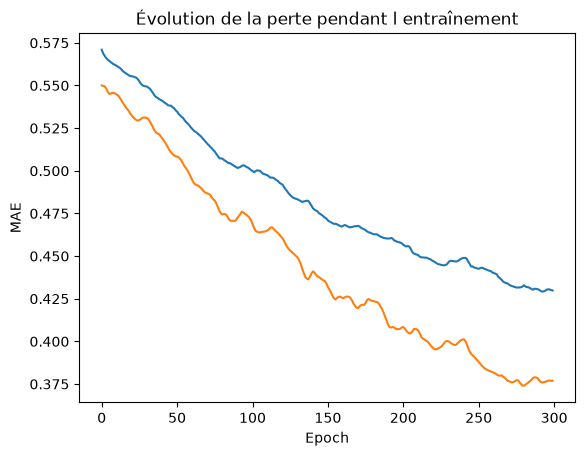

In [76]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Évolution de la perte pendant l entraînement')
plt.show()

In [77]:
predictions_scaled = model.predict(X_test_scaled)  # ou X_test_scaled selon ton setup
predictions_reelles = scaler_y.inverse_transform(predictions_scaled)

from sklearn.metrics import mean_absolute_error
mae_reelle = mean_absolute_error(y_test, predictions_reelles)
print(mae_reelle)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
7.477690696716309
